In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [13]:
class CalcState(TypedDict):

    a: float
    b: float

    sum: float
    product: float


def calc_sum(state):
    
    a = state['a']
    b = state['b']

    sum_ = a + b
    return {"sum": sum_}

def calc_product(state):
    a = state['a']
    b = state['b']

    return {"product": a * b}

In [14]:
graph  = StateGraph(CalcState)

graph.add_node("calc_sum", calc_sum)
graph.add_node("calc_product", calc_product)

graph.add_edge(START, "calc_sum")

graph.add_edge(START, "calc_product")

graph.add_edge("calc_sum", END)

graph.add_edge("calc_product", END)

In [15]:
wf = graph.compile()

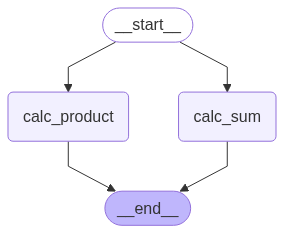

In [16]:
wf

In [17]:
init = {"a":2, "b":6}

final = wf.invoke(init)

In [18]:
final

{'a': 2, 'b': 6, 'sum': 8, 'product': 12}